#### importing neccessary librarie

In [1]:
import pandas as pd
import numpy as np

##### here we want to read our raw datasets with csv

In [2]:
globex_df = pd.read_csv(r'C:\Users\thefa\OneDrive\Desktop\bonga case study\Globex_retail_case_study\rawdata\globex_retail_data - globex_retail_data.csv')

In [3]:
globex_df.head()

,Customer_ID,Order_ID,Order_Date,Product_Category,Product_Sub_Category,Quantity,Price,Discount,Customer_Location,Revenue
0,CUST_013738,ORD_00102406,2023-01-01,Home & Garden,Gardening Tools,1,419.19,0.00,TN,419.1900
1,CUST_011726,ORD_00102902,2023-01-01,Electronics,Laptops,1,222.37,0.09,TN,202.3567
2,CUST_010891,ORD_00103864,2023-01-01,Electronics,Laptops,6,1107.65,0.00,IN,6645.9000
3,CUST_011452,ORD_00103560,2023-01-01,Electronics,Gaming Consoles,5,288.84,0.00,MA,1444.2000
4,CUST_010886,ORD_00100632,2023-01-02,Electronics,Headphones,1,191.27,0.00,AZ,191.2700


In [4]:
globex_df.columns

Index(['Customer_ID', 'Order_ID', 'Order_Date', 'Product_Category',
       'Product_Sub_Category', 'Quantity', 'Price', 'Discount',
       'Customer_Location', 'Revenue'],
      dtype='object')

##### data cleaning and transformation

In [5]:
globex_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           5000 non-null   object 
 1   Order_ID              5000 non-null   object 
 2   Order_Date            5000 non-null   object 
 3   Product_Category      5000 non-null   object 
 4   Product_Sub_Category  5000 non-null   object 
 5   Quantity              5000 non-null   int64  
 6   Price                 5000 non-null   float64
 7   Discount              5000 non-null   float64
 8   Customer_Location     5000 non-null   object 
 9   Revenue               5000 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 390.8+ KB


In [6]:
globex_df['Order_Date'].head()

0    2023-01-01
1    2023-01-01
2    2023-01-01
3    2023-01-01
4    2023-01-02
Name: Order_Date, dtype: object

In [7]:
globex_df['Order_Date'] = pd.to_datetime(globex_df['Order_Date'], format="%Y-%m-%d", dayfirst=True)

In [8]:
globex_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Customer_ID           5000 non-null   object        
 1   Order_ID              5000 non-null   object        
 2   Order_Date            5000 non-null   datetime64[ns]
 3   Product_Category      5000 non-null   object        
 4   Product_Sub_Category  5000 non-null   object        
 5   Quantity              5000 non-null   int64         
 6   Price                 5000 non-null   float64       
 7   Discount              5000 non-null   float64       
 8   Customer_Location     5000 non-null   object        
 9   Revenue               5000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(5)
memory usage: 390.8+ KB


##### Now the data is cleaned, no missing or incomplete values, which the non-null are all unique and same values now, we will now go ahead to create their unique tables

In [9]:
customers_df = globex_df[['Customer_ID', 'Customer_Location']].copy().drop_duplicates().reset_index(drop=True)
customers_df.head()

,Customer_ID,Customer_Location
0,CUST_013738,TN
1,CUST_011726,TN
2,CUST_010891,IN
3,CUST_011452,MA
4,CUST_010886,AZ


In [10]:
orders_df = globex_df[['Order_ID', 'Customer_ID', 'Order_Date']].copy().drop_duplicates().reset_index(drop=True)
orders_df.head()

,Order_ID,Customer_ID,Order_Date
0,ORD_00102406,CUST_013738,2023-01-01
1,ORD_00102902,CUST_011726,2023-01-01
2,ORD_00103864,CUST_010891,2023-01-01
3,ORD_00103560,CUST_011452,2023-01-01
4,ORD_00100632,CUST_010886,2023-01-02


In [11]:
order_lines_df = globex_df[['Order_ID', 'Product_Sub_Category', 'Quantity', 'Price', 'Discount', 'Revenue']].copy().drop_duplicates().reset_index(drop=True)
order_lines_df.head()

,Order_ID,Product_Sub_Category,Quantity,Price,Discount,Revenue
0,ORD_00102406,Gardening Tools,1,419.19,0.00,419.1900
1,ORD_00102902,Laptops,1,222.37,0.09,202.3567
2,ORD_00103864,Laptops,6,1107.65,0.00,6645.9000
3,ORD_00103560,Gaming Consoles,5,288.84,0.00,1444.2000
4,ORD_00100632,Headphones,1,191.27,0.00,191.2700


In [12]:
products_df = globex_df[['Product_Sub_Category', 'Product_Category']].copy().drop_duplicates().reset_index(drop=True)
products_df.head()

,Product_Sub_Category,Product_Category
0,Gardening Tools,Home & Garden
1,Laptops,Electronics
2,Gaming Consoles,Electronics
3,Headphones,Electronics
4,Shoes,Clothing


#### Data loading
##### Now we will export and start loading our data into our cleaned data file (dataframes)
##### we will be loading it into csv files


In [13]:
customers_df.to_csv(r'C:\Users\thefa\OneDrive\Desktop\bonga case study\Globex_retail_case_study\rawdata\cleaneddata\customers.csv', index=False)
orders_df.to_csv(r'C:\Users\thefa\OneDrive\Desktop\bonga case study\Globex_retail_case_study\rawdata\cleaneddata\orders.csv', index=False)
order_lines_df.to_csv(r'C:\Users\thefa\OneDrive\Desktop\bonga case study\Globex_retail_case_study\rawdata\cleaneddata\order_lines.csv', index=False)
products_df.to_csv(r'C:\Users\thefa\OneDrive\Desktop\bonga case study\Globex_retail_case_study\rawdata\cleaneddata\products.csv', index=False)

#### Generating Insights with Pandas: Problem solving;

##### Q1. Which product category has generated the most revenue?

In [14]:
globex_df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False).head(1)


Product_Category
Electronics    2.079574e+06
Name: Revenue, dtype: float64

##### Q2. Which product subcategories generate the most revenue?

In [15]:
globex_df.groupby('Product_Sub_Category')['Revenue'].sum().sort_values(ascending=False).head(1)

Product_Sub_Category
Smart Watches    403335.4208
Name: Revenue, dtype: float64

##### Q3. Which customer segment has the highest average order value?

In [16]:
order_value = globex_df.groupby('Order_ID')['Revenue'].sum()
globex_df.groupby('Customer_ID')['Order_ID'].apply(lambda x: order_value[x].mean()).sort_values(ascending=False).head(1)

Customer_ID
CUST_011802    13819.84
Name: Order_ID, dtype: float64

##### Q4. What is the average discount applied to high-value customers?

In [17]:
customer_revenue = globex_df.groupby('Customer_ID')['Revenue'].sum()
threshold = customer_revenue.quantile(0.9)  # top 10%
high_value_customers = customer_revenue[customer_revenue >= threshold].index

globex_df[globex_df['Customer_ID'].isin(high_value_customers)]['Discount'].mean()

np.float64(0.055302114803625374)

##### Q5. Which geographic locations have the highest concentration of high-value customers?

In [18]:
high_value_locations = (
    globex_df.loc[globex_df['Customer_ID'].isin(high_value_customers)]
    .groupby('Customer_Location')['Customer_ID']
    .nunique()
    .sort_values(ascending=False)
)

In [19]:
high_value_locations.head(5)

Customer_Location
IL    31
CO    30
LA    29
AL    27
MI    27
Name: Customer_ID, dtype: int64

##### Q6. How does the discount rate impact total sales across product categories?


In [20]:
globex_df.groupby(['Product_Category', 'Discount'])['Revenue'].sum().reset_index().head(5)

,Product_Category,Discount,Revenue
0,Beauty,0.00,100612.2700
1,Beauty,0.05,1437.7395
2,Beauty,0.06,2868.0622
3,Beauty,0.07,1138.3851
4,Beauty,0.08,2240.2920


##### Q7. Identify trends in purchase behavior over time (e.g., monthly).

<Axes: title={'center': 'Monthly Revenue Trends'}, xlabel='Month'>

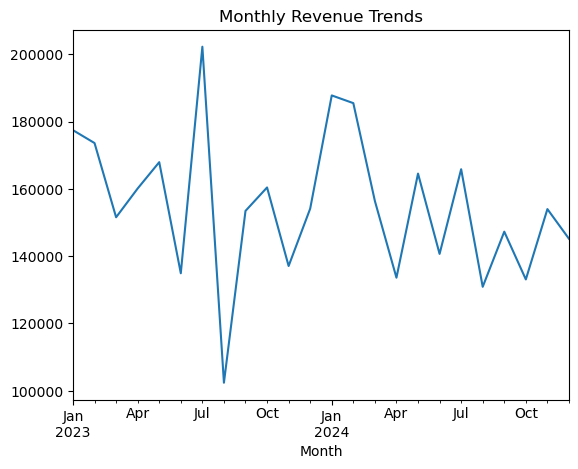

In [21]:
globex_df['Order_Date'] = pd.to_datetime(globex_df['Order_Date'], errors='coerce')
globex_df['Month'] = globex_df['Order_Date'].dt.to_period('M')

monthly_trends = globex_df.groupby('Month')['Revenue'].sum()
monthly_trends.plot(kind='line', title='Monthly Revenue Trends')
